In [1]:
import numpy as np
import spin_hamiltonian as spin
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt
import matplotlib.colors as clr
from qil_helpers.Ben import General as Ben

from IPython.display import display, Latex
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode, iplot
from pathos.multiprocessing import ProcessingPool as Pool


In [2]:
pts=50
r=100
thetas=np.tile(np.linspace(0,np.pi,pts),pts)
phis=np.repeat(np.linspace(0,2*np.pi,pts),pts)

# x=r*np.outer(np.sin(thetas),np.cos(phis))
# y=r*np.outer(np.sin(thetas),np.sin(phis))
# z=r*np.outer(np.ones(np.size(phis)),np.cos(thetas))
x=r*np.sin(thetas)*np.cos(phis)
y=r*np.sin(thetas)*np.sin(phis)
z=r*np.cos(thetas)
vec=np.vstack([x,y,z])
direction=np.array([1,1,1])
#idx=np.squeeze(np.where(np.dot(direction,vec)>=0))
idx=np.arange(0,vec.shape[-1],1)
vec=vec[:,idx]



In [3]:
%%script False
%matplotlib widget
#%matplotlib inline

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(*vec)
#ax.plot_surface(x,y,z)
#ax.scatter(*bsph.T)
plt.show()


Couldn't find program: 'False'


In [4]:
ground=spin.hamilFromYAML("./ion_params/Er_YSO_site1_ground.yml",IOveride=0)
excited=spin.hamilFromYAML("./ion_params/Er_YSO_site1_excited.yml",IOveride=0)
#ground=excited
Hcalc=lambda B,self: self.electronicZeeman(B)#+self.HHF#+self.HQP+self.nuclearZeeman(B)
ground.Hfunc=Hcalc
excited.Hfunc=Hcalc

Ag=ground.genAMatrix(spin.muB*ground.gE,ground.S,electronic=True)
Ae=excited.genAMatrix(spin.muB*excited.gE,excited.S,electronic=True)


{'Spin': {'Espin': '1/2', 'Ispin': '7/2'}, 'Hyperfine': {'A': 'np.matrix([[304.8,-252.8,-307.6],[-252.8,778.0,710.2],[-307.6,710.2,616.2]])*1e6*h', 'A_rot': 'np.array([0,0,0])'}, 'Quadrupole': {'Q': 'np.matrix([[10.1,-10.1,-14.0],[-10.1,-6.3,-15.2],[-14.0,-15.6,-3.8]])*1e6*h', 'Q_rot': 'np.array([0,0,0])'}, 'E_Zeeman': {'g': 'np.matrix([[2.85,-2.98,-3.63],[-2.98,9.00,5.51],[3.63,5.51,5.19]])', 'g_rot': 'np.array([0,0,0])'}, 'N_Zeeman': {'mu': '-0.56'}, 'Oscillator': {'par': 'np.block([[np.eye(odim),np.zeros([odim,odim])],[np.zeros([odim,odim]),np.eye(odim)]])', 'perp': 'np.block([[np.zeros([odim,odim]),1*np.eye(odim)],[np.eye(odim),np.zeros([odim,odim])]])', 'perp_T': 'np.block([[np.zeros([odim,odim]),1j*np.eye(odim)],[-1j*np.eye(odim),np.zeros([odim,odim])]])'}}
{'Spin': {'Espin': '1/2', 'Ispin': '7/2'}, 'Hyperfine': {'A': 'np.matrix([[307.9,-327.5,-464.8],[-327.5,607.8,676.7],[-464.8,676.7,980.5]])*1e6*h', 'A_rot': 'np.array([0,0,0])'}, 'Quadrupole': {'Q': 'np.matrix([[56.0,1.66,5.80

In [5]:
def tSweep(state,Bs):
    F=np.zeros((len(Bs),state.dim))
    Fp=np.zeros((len(Bs),state.dim,3))


    for i,x in enumerate(Bs):
        B = x            
        HG = state.calcH(B)
    
        #get the eigen frequencies and vectors at this B field
        FG,VG = state.getEigFreq(HG)
        F[i,:]=FG

        for j in range(3):
            Fp[i,:,j]= state.firstOrderEnergySensitivity(VG,state.A[j])
    return F,Fp

def multiSweepOptical(Bs):
    FSG=np.zeros((len(Bs),ground.dim))
    FSE=np.zeros((len(Bs),excited.dim))


    FpG=np.zeros((len(Bs),ground.dim,3))
    FpE=np.zeros((len(Bs),ground.dim,3))

    #if __name__ == '__main__':
    with Pool() as pool:
        #F,Fp,Fpp=pool.map(ground.calcBOptParams,Bs)
        for i,result in enumerate(pool.map(ground.calcBOptParams,Bs)):#range(Bs.shape[0]):
            FSG[i,:],FpG[i,:,:],_=result

        for i,result in enumerate(pool.map(excited.calcBOptParams,Bs)):#range(Bs.shape[0]):
            FSE[i,:],FpE[i,:,:],_=result

    return spin.eachElemFunc(FSG,FSE,ax=1),spin.eachElemFunc(FpG,FpE,ax=1)


In [6]:
T,Td=multiSweepOptical(vec.T)
#T,Td=tSweep(ground,20E-3*vec.T)


C:\Users\neb16\AppData\Local\Temp/ipykernel_31940/776603676.py:30: ComplexWarning:

Casting complex values to real discards the imaginary part

C:\Users\neb16\AppData\Local\Temp/ipykernel_31940/776603676.py:33: ComplexWarning:

Casting complex values to real discards the imaginary part



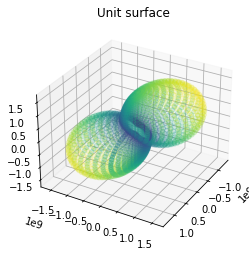

In [ ]:
%matplotlib inline
idx=1
cm=plt.get_cmap('viridis',100)
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
#scale=vec/np.log10(T[:,idx].T)
scale=vec*T[:,idx].T
iso=vec/T[:,idx].T
ax.scatter(*scale,c=cm(T[:,idx]/np.max(T[:,idx])),alpha=0.2)
plt.title("Unit surface")
ax.view_init(elev=30., azim=30)
Ben.goodFigSave("../images/Experimental Fits/Testing/","unit_surface.png")
plt.show()
plt.close()


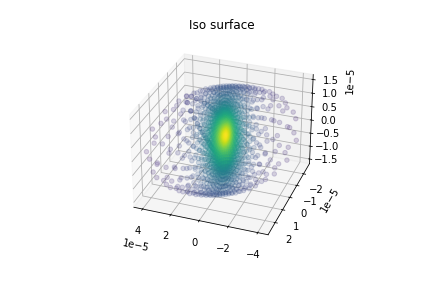

In [12]:
%matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

iso=vec/T[:,idx].T
isodB=vec/np.log10(T[:,idx].T)
ax.scatter(*iso,c=cm(T[:,idx]/np.max(T[:,idx])),alpha=0.2)
ax.view_init(elev=30., azim=110)
plt.title("Iso surface")
Ben.goodFigSave("../images/Experimental Fits/Testing/","iso_surface.png")

plt.show()
#plt.close()


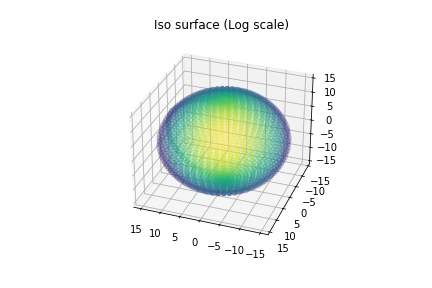

In [11]:
%matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(*isodB,c=cm(T[:,idx]/np.max(T[:,idx])),alpha=0.2)
ax.view_init(elev=30., azim=110)
plt.title("Iso surface (Log scale)")
Ben.goodFigSave("../images/Experimental Fits/Testing/","iso_surface_dB.png")

plt.show()
#plt.close()


C:\Users\neb16\AppData\Local\Temp/ipykernel_31940/776603676.py:15: ComplexWarning:

Casting complex values to real discards the imaginary part



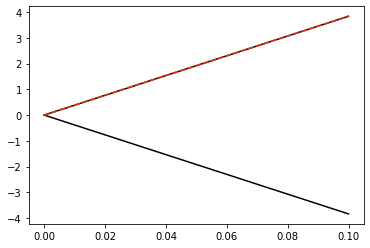

In [10]:
plt.close()
%matplotlib inline

Bm=np.linspace(0,100E-3,500)
Bu=np.array([1,0,0])

Tcalc,_=tSweep(ground, np.outer(Bu,Bm).T)
Tzeeman,_=ground.getEigFreq(ground.electronicZeeman(Bu))
THF,_=ground.getEigFreq(ground.HHF)
Tunit=Tzeeman-THF
plt.plot(Bm,Tcalc,'k')
plt.plot(Bm,Tcalc[:,idx],'C1--')
plt.plot(Bm,Tunit[idx]*Bm,'C3--')
#plt.ylim([0,None])
plt.show()
plt.close()